# Esercizio 2: Confronto tra Insertion Sort e Quick Sort

**Nome:** Andrea
**Cognome:** Petrucci
**Matricola:** 7050922

Questo notebook analizza due algoritmi di ordinamento fondamentali: Insertion Sort e Quick Sort. Esamineremo il loro funzionamento, complessità temporale e prestazioni pratiche attraverso esempi e confronti diretti. L'obiettivo è comprendere le differenze tra i due approcci e identificare i contesti in cui ciascun algoritmo è più efficiente.

In [33]:
import random

def generate_random_array(size):
    """Genera un array di numeri casuali con dimensione in input."""
    return [random.randint(0, 100) for _ in range(size)]

def generate_sorted_array(size):
    """Genera un array già ordinato con dimensione in input."""
    return list(range(size))

def generate_reverse_sorted_array(size):
    """Genera un array ordinato in modo decrescente con dimensione in input."""
    return list(range(size, 0, -1))

def generate_almost_sorted_array(size, swap_count=None):
    """Genera un array quasi ordinato con dimensione in input."""
    arr = list(range(size))
    if swap_count is None:
        swap_count = max(1, size // 20)  # Scambia il 5% degli elementi, minimo 1
    for _ in range(swap_count):
        i = random.randint(0, size - 1)
        j = random.randint(0, size - 1)
        arr[i], arr[j] = arr[j], arr[i]
    return arr

def generate_array_with_many_duplicates(size, value_range=10):
    """Genera un array con molti elementi duplicati con dimensione in input."""
    return [random.randint(0, value_range) for _ in range(size)]

## Insertion Sort
Costruisce l'array ordinato un elemento alla volta, inserendo ogni nuovo elemento nella posizione corretta tra quelli già ordinati. È efficiente per array piccoli o quasi ordinati, con complessità temporale $O(n^2)$ nel caso peggiore e $O(n)$ nel caso migliore.

In [34]:
def insertion_sort(arr):
    """Ordina un array utilizzando l'algoritmo Insertion Sort."""
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and key < arr[i]:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key
    return arr

## Quick Sort
È un algoritmo **Divide et Impera** che seleziona un elemento come pivot, partiziona l'array mettendo gli elementi minori a sinistra e i maggiori a destra, e ordina ricorsivamente i sottoarray. La versione classica possiede una complessità temporale media di $O(n \lg n)$, ma precipita a $O(n^2)$ nel caso peggiore (array già ordinati o inversamente ordinati). Per ovviare a questo limite intrinseco, in questa sede è stata implementata la versione randomizzata dell'algoritmo. L'estrazione casuale del pivot svincola le prestazioni dalla disposizione iniziale dei dati, mantenendo l'esecuzione estremamente efficiente nella pratica.

In [35]:
def partition(A,p,r):
    i=p-1
    for j in range (p,r):
        if A[j] <= A[r]:
            i = i+1
            A[i], A[j] = A[j], A[i]
    A[i+1], A[r] = A[r], A[i+1]
    return i+1

def randomized_partition(A,p,r):
    """Sceglie un pivot casuale e lo scambia con A[r] prima della partizione."""
    i = random.randint(p, r)
    A[i], A[r] = A[r], A[i]
    return partition(A,p,r)

def quicksort(A,p,r):
    if p<r:
        q = randomized_partition(A,p,r)
        quicksort(A,p,q-1)
        quicksort(A,q+1,r)

## Benchmark e Confronto
Misuriamo il tempo di esecuzione di Insertion Sort e Quick Sort su array di dimensioni e ordinamenti diversi e confrontiamo le prestazioni tramite tabelle e grafici.

### Prerequisiti di sistema
Per la corretta esecuzione di questo Notebook e la visualizzazione dei grafici, è necessario che nel kernel Python sia installata la libreria `matplotlib`. 
Qualora non fosse presente, è possibile installarla eseguendo il seguente comando in un terminale o in una cella temporanea:
`%pip install matplotlib`

### Benchmark 1: Array con numeri casuali

Testiamo sia Insertion Sort che Quick Sort su un array con numeri casuali, per confrontare le loro prestazioni.


Dimensione	Insertion Sort	Quick Sort
--------------------------------------------------
100		0.000151	0.000087
500		0.005788	0.001495
1000		0.133834	0.007983
2000		0.088118	0.004788
5000		0.546825	0.019708


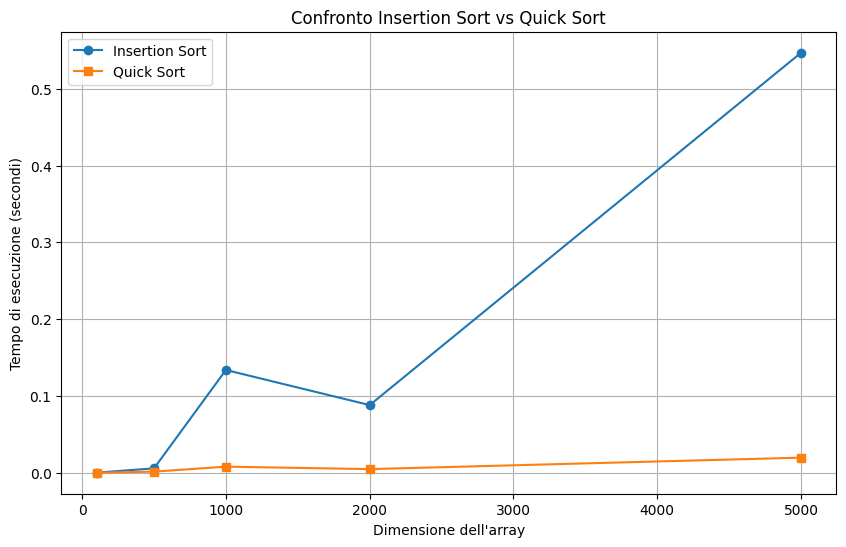

In [36]:
import time
import matplotlib.pyplot as plt

def benchmark_sorting_algorithms():
    """Esegue benchmark su Insertion Sort e Quick Sort e mostra i risultati."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_times = []
    quick_times = []

    for size in sizes:
        arr = generate_random_array(size)
        
        # Benchmark Insertion Sort
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_times.append(end - start)
        
        # Benchmark Quick Sort
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("-" * 50)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_times[i]:.6f}\t{quick_times[i]:.6f}")
    
    # Crea grafico
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, insertion_times, marker='o', label='Insertion Sort')
    plt.plot(sizes, quick_times, marker='s', label='Quick Sort')
    plt.xlabel('Dimensione dell\'array')
    plt.ylabel('Tempo di esecuzione (secondi)')
    plt.title('Confronto Insertion Sort vs Quick Sort')
    plt.legend()
    plt.grid(True)
    plt.show()

# Esegui benchmark
benchmark_sorting_algorithms()

### Benchmark 2: Array Ordinato (crescente)
Testiamo sia Insertion Sort che Quick Sort su un array ordinato in modo crescente, per confrontare le loro prestazioni nel caso migliore per Insertion Sort e il potenziale peggiore di Quick Sort.


Dimensione	Insertion Sort	Quick Sort
-----------------------------------------------------------------
100		0.000013	0.000106
500		0.000079	0.001678
1000		0.000126	0.001294
2000		0.000200	0.002854
5000		0.000543	0.008387


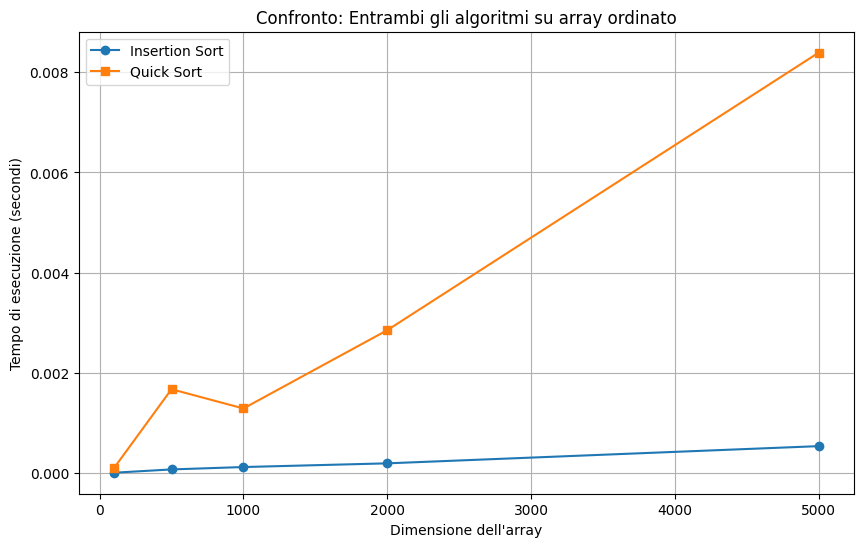

In [37]:
def benchmark_both_on_sorted():
    """Benchmark dove entrambi gli algoritmi ricevono un array già ordinato."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_sorted_times = []
    quick_sorted_times = []

    for size in sizes:
        # Genera array già ordinato
        arr = generate_sorted_array(size)
        
        # Insertion Sort sull'array già ordinato (caso migliore)
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_sorted_times.append(end - start)
        
        # Quick Sort sull'array già ordinato
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_sorted_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("-" * 65)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_sorted_times[i]:.6f}\t{quick_sorted_times[i]:.6f}")
    
    # Crea grafico (solo se matplotlib è disponibile)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_sorted_times, marker='o', label='Insertion Sort')
        plt.plot(sizes, quick_sorted_times, marker='s', label='Quick Sort')
        plt.xlabel('Dimensione dell\'array')
        plt.ylabel('Tempo di esecuzione (secondi)')
        plt.title('Confronto: Entrambi gli algoritmi su array ordinato')
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("\nMatplotlib non installato, impossibile visualizzare il grafico.")

# Esegui benchmark
benchmark_both_on_sorted()

### Benchmark 3: Array Ordinato (decrescente)
Testiamo sia Insertion Sort che Quick Sort su un array ordinato in modo decrescente, per confrontare le loro prestazioni nel caso peggiore per Insertion Sort.

Dimensione	Insertion Sort	Quick Sort
----------------------------------------------------------------------
100		0.000289	0.000096
500		0.008890	0.000661
1000		0.042254	0.001164
2000		0.170958	0.002744
5000		1.122988	0.007700


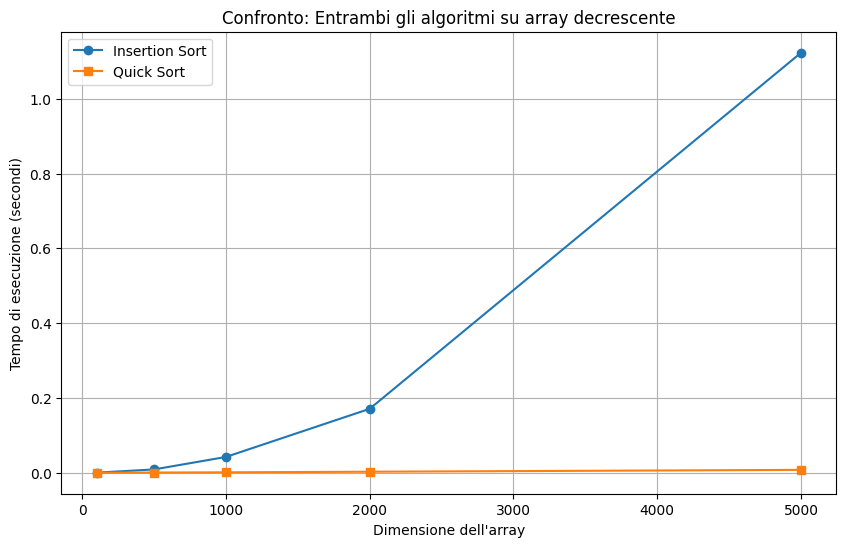

In [38]:
def benchmark_both_on_reverse_sorted():
    """Benchmark dove entrambi gli algoritmi ricevono un array ordinato in modo decrescente."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_reverse_times = []
    quick_reverse_times = []

    for size in sizes:
        # Genera array ordinato in modo decrescente
        arr = generate_reverse_sorted_array(size)
        
        # Insertion Sort sull'array ordinato in modo decrescente (caso peggiore)
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_reverse_times.append(end - start)
        
        # Quick Sort sull'array ordinato in modo decrescente
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_reverse_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("-" * 70)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_reverse_times[i]:.6f}\t{quick_reverse_times[i]:.6f}")
    
    # Crea grafico (solo se matplotlib è disponibile)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_reverse_times, marker='o', label='Insertion Sort')
        plt.plot(sizes, quick_reverse_times, marker='s', label='Quick Sort')
        plt.xlabel('Dimensione dell\'array')
        plt.ylabel('Tempo di esecuzione (secondi)')
        plt.title('Confronto: Entrambi gli algoritmi su array decrescente')
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("\nMatplotlib non installato, impossibile visualizzare il grafico.")

# Esegui benchmark
benchmark_both_on_reverse_sorted()

### Benchmark 4: Array Quasi Ordinato
Testiamo sia Insertion Sort che Quick Sort su un array quasi ordinato, un contesto comune in molte applicazioni reali.

Dimensione	Insertion Sort	Quick Sort
		(array quasi ordinato)	(array quasi ordinato)
---------------------------------------------------------------------------
100		0.000041	0.000113
500		0.000870	0.000949
1000		0.002742	0.001251
2000		0.012763	0.002995
5000		0.077920	0.008241


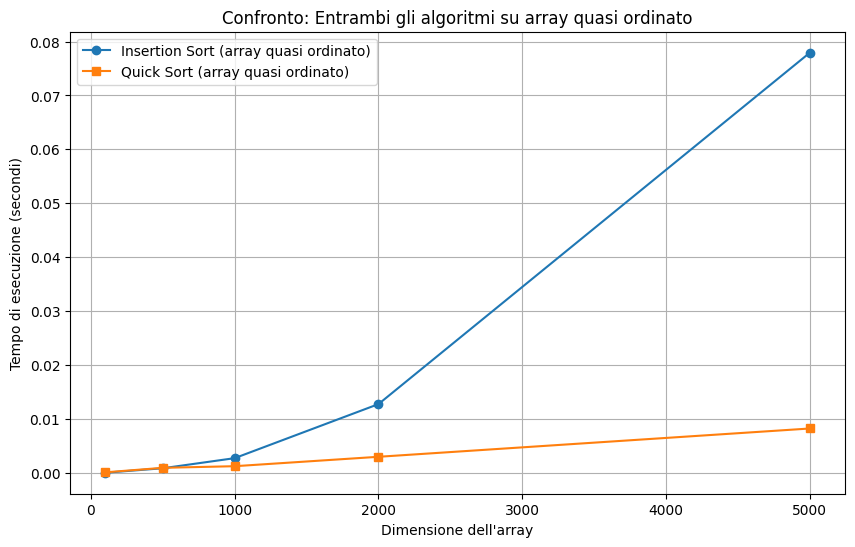

In [39]:
def benchmark_both_on_almost_sorted():
    """Benchmark dove entrambi gli algoritmi ricevono un array quasi ordinato."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_almost_times = []
    quick_almost_times = []

    for size in sizes:
        # Genera array quasi ordinato
        arr = generate_almost_sorted_array(size)
        
        # Insertion Sort sull'array quasi ordinato
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_almost_times.append(end - start)
        
        # Quick Sort sull'array quasi ordinato
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_almost_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("\t\t(array quasi ordinato)\t(array quasi ordinato)")
    print("-" * 75)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_almost_times[i]:.6f}\t{quick_almost_times[i]:.6f}")
    
    # Crea grafico (solo se matplotlib è disponibile)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_almost_times, marker='o', label='Insertion Sort (array quasi ordinato)')
        plt.plot(sizes, quick_almost_times, marker='s', label='Quick Sort (array quasi ordinato)')
        plt.xlabel('Dimensione dell\'array')
        plt.ylabel('Tempo di esecuzione (secondi)')
        plt.title('Confronto: Entrambi gli algoritmi su array quasi ordinato')
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("\nMatplotlib non installato, impossibile visualizzare il grafico.")

# Esegui benchmark
benchmark_both_on_almost_sorted()

### Benchmark 5: Array con Molti Duplicati
Testiamo sia Insertion Sort che Quick Sort su un array con molti elementi duplicati, un contesto che si verifica spesso in dati reali.


Dimensione	Insertion Sort	Quick Sort
		(array con duplicati)	(array con duplicati)
--------------------------------------------------------------------------------
100		0.000148	0.000130
500		0.004356	0.001521
1000		0.019968	0.005096
2000		0.081379	0.018505
5000		0.497773	0.110736


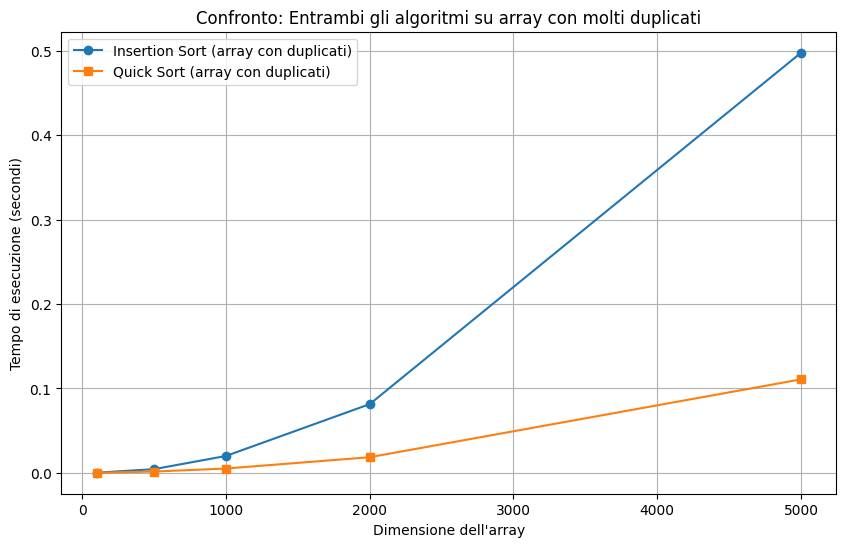

In [40]:
def benchmark_both_on_many_duplicates():
    """Benchmark dove entrambi gli algoritmi ricevono un array con molti duplicati."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_duplicates_times = []
    quick_duplicates_times = []

    for size in sizes:
        # Genera array con molti duplicati
        arr = generate_array_with_many_duplicates(size)
        
        # Insertion Sort sull'array con molti duplicati
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_duplicates_times.append(end - start)
        
        # Quick Sort sull'array con molti duplicati
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_duplicates_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("\t\t(array con duplicati)\t(array con duplicati)")
    print("-" * 80)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_duplicates_times[i]:.6f}\t{quick_duplicates_times[i]:.6f}")
    
    # Crea grafico (solo se matplotlib è disponibile)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_duplicates_times, marker='o', label='Insertion Sort (array con duplicati)')
        plt.plot(sizes, quick_duplicates_times, marker='s', label='Quick Sort (array con duplicati)')
        plt.xlabel('Dimensione dell\'array')
        plt.ylabel('Tempo di esecuzione (secondi)')
        plt.title('Confronto: Entrambi gli algoritmi su array con molti duplicati')
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("\nMatplotlib non installato, impossibile visualizzare il grafico.")

# Esegui benchmark
benchmark_both_on_many_duplicates()